In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
null_columns_a = ["life_expectancy", "adult_mortality", "bmi", "polio", "diphtheria", "thinness_1_19_years", "thinness_5_9_years"]
drop_columns = [col for col in null_columns_a if col]
null_columns_b = ["alcohol", "hepatitis_b", "total_expenditure", "gdp", "population", "schooling", "income_composition_of_resources"]
imp_cols = [col for col in null_columns_b if col]
imp_mean_col = ["alcohol", "total_expenditure", "gdp", "population", "income_composition_of_resources"]
imp_median_col = ["hepatitis_b", "schooling"]


In [ ]:
data = (
    pd.read_csv("life_expectancy_data.csv")
    .rename(columns= lambda col: col.strip().lower().replace(" ", "_").replace("-", "_"))
    .dropna(subset = drop_columns, how = "any")
)
data

In [ ]:
missing_data = data.isnull().sum()
total_obv = data.shape[0]
print(f"Total Sum of Missing Data: {missing_data}")
print(f"Total Number of Observations/Rows:{total_obv}")

In [ ]:
missing_percent = missing_data / total_obv * 100
missing_percent

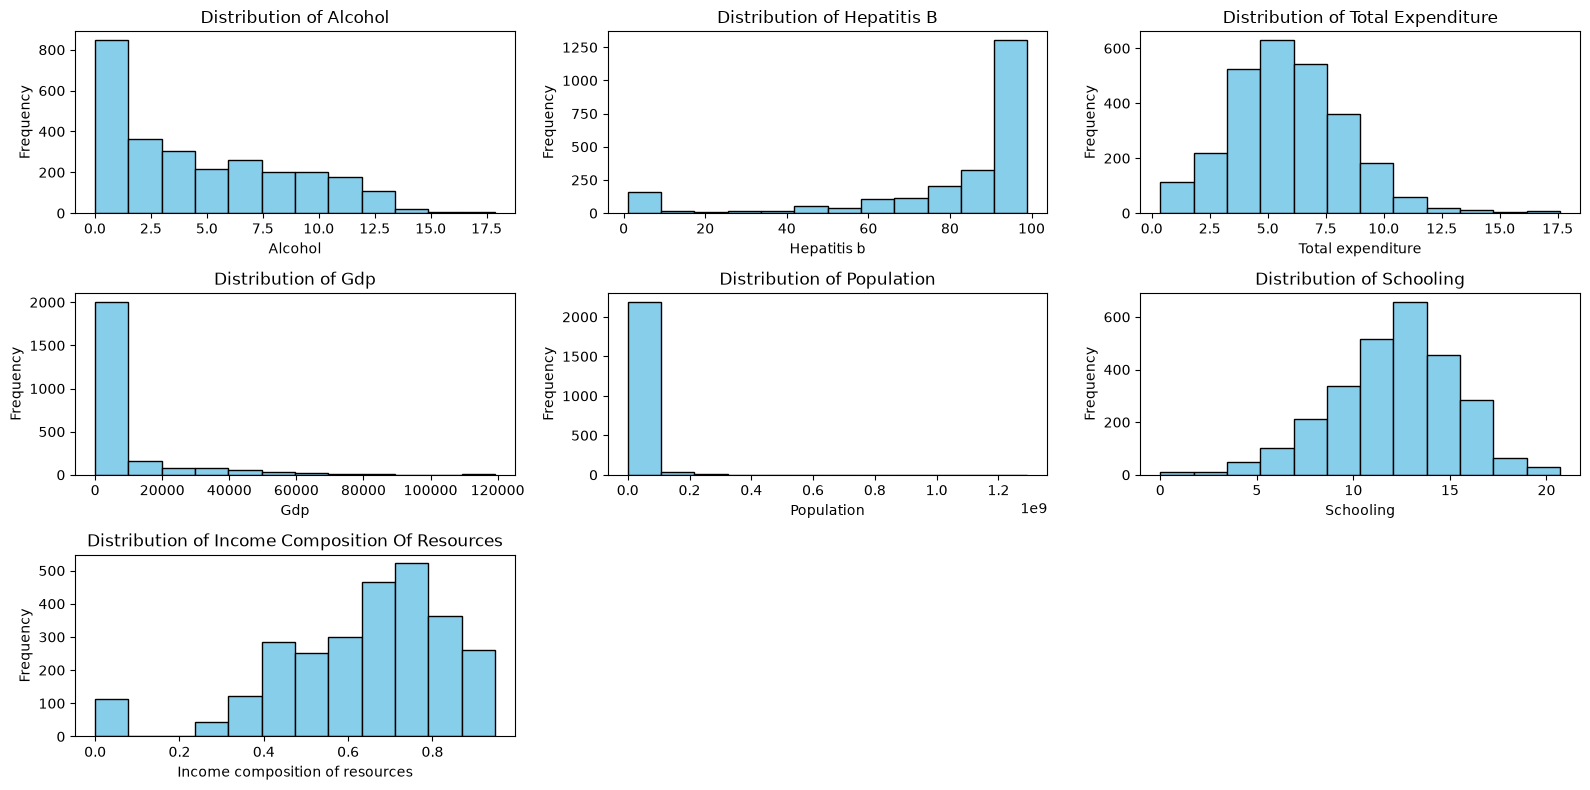

In [8]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (16, 8))
axes = axes.flatten()
for i, col in enumerate(imp_cols):
    axes[i].hist(data[col], bins = 12
    , color = "skyblue", edgecolor = "black")
    axes[i].set_title(f"Distribution of {col.capitalize().replace("_", " ").title()}")
    axes[i].set_xlabel(col.capitalize().replace("_", " "))
    axes[i].set_ylabel("Frequency")
for j in range(len(imp_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()    

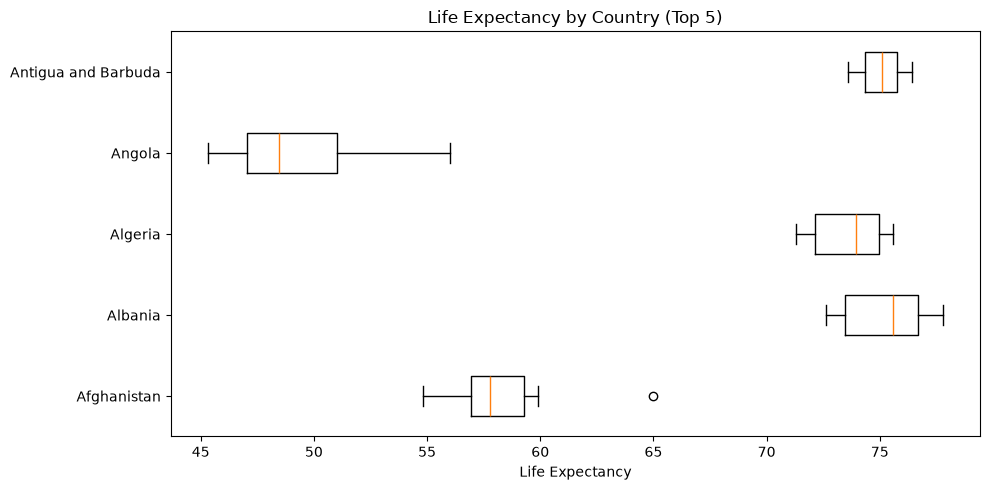

In [ ]:
#Creating Boxplots for the Top 5 Countries
selected_top_countries = (
    data["country"]
    .value_counts()
    .head()
    .index.tolist()
)
data_by_top_countries = [data[data["country"] == country]["life_expectancy"] for country in selected_top_countries]

fig, ax = plt.subplots(figsize = (10, 5))
ax.boxplot(data_by_top_countries, tick_labels = selected_top_countries, orientation = "horizontal")
ax.set_title("Life Expectancy by Country (Top 5)")
ax.set_xlabel("Life Expectancy")
plt.tight_layout()
plt.show();


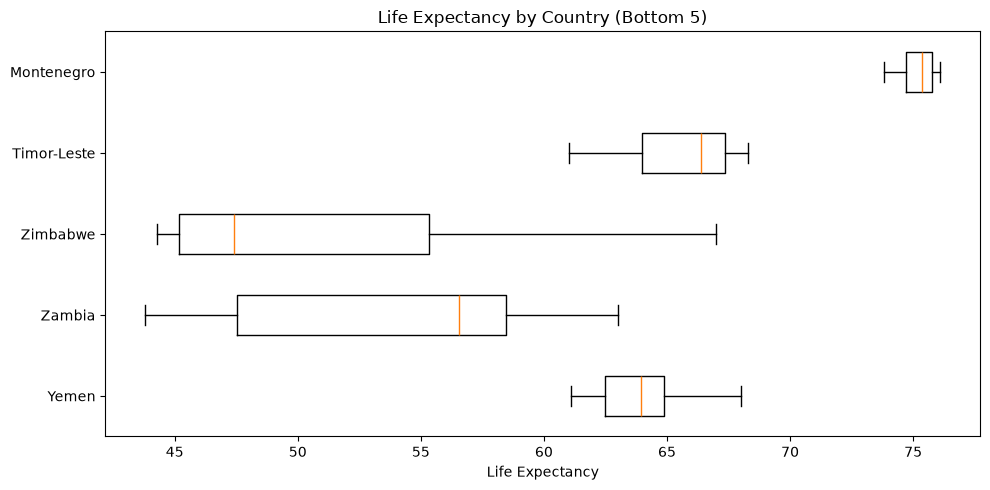

In [ ]:
#Creating Boxplots for the Bottom 5 Countries
selected_bottom_countries = (
    data["country"]
    .value_counts()
    .tail()
    .index.tolist()
)
data_by_bottom_countries = [data[data["country"] == country]["life_expectancy"] for country in selected_bottom_countries]
fig, ax = plt.subplots(figsize = (10, 5))
ax.boxplot(data_by_bottom_countries, tick_labels = selected_bottom_countries, orientation = "horizontal")
ax.set_title("Life Expectancy by Country (Bottom 5)")
ax.set_xlabel("Life Expectancy")
plt.tight_layout()
plt.show()

In [11]:
for col in imp_mean_col:
    mean_val = data[col].mean()
    data[col] = data[col].fillna(mean_val)  

for col in imp_median_col:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val) 

In [ ]:
num_columns = data.select_dtypes("number")
corr_matrix_cols = (
    num_columns.corr()
)
corr_mask = np.triu(np.ones_like(corr_matrix_cols, dtype = bool))
masked_corr_matrix = corr_matrix_cols.mask(corr_mask)

cleaned_corr_matrix = (
    masked_corr_matrix.unstack()
    .dropna()
    .reset_index()
)
cleaned_corr_matrix.columns = ["Metric 1", "Metric 2", "Correlation"]
cleaned_corr_matrix["Abs_Corr"] = cleaned_corr_matrix["Correlation"].abs()
cleaned_corr_matrix = cleaned_corr_matrix.sort_values(by = "Abs_Corr", ascending = True).drop(columns = ["Abs_Corr"]).reset_index(drop = True)
cleaned_corr_matrix

In [ ]:
target_var = "life_expectancy"
target_corr = (
    cleaned_corr_matrix[(cleaned_corr_matrix["Metric 1"] == target_var) | (cleaned_corr_matrix["Metric 2"] == target_var)]
    .copy()
    .sort_values(ascending = False, by = "Correlation", key = abs)
    .reset_index(drop = True)
)

target_corr 